# XRAY QCNN v1

# 0) IMPORTS

In [1]:
import os
import time
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

import pennylane as qml

from sklearn.metrics import (
    roc_curve, roc_auc_score, average_precision_score,
    precision_recall_curve, accuracy_score, f1_score,
    confusion_matrix, classification_report, precision_score
)

# 1) CONFIGURACIÓN GLOBAL

In [2]:
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float32)

print("Using device:", DEVICE)
print("Torch default dtype:", torch.get_default_dtype())

Using device: cuda:0
Torch default dtype: torch.float32


# 2) HIPERPARÁMETROS Y RUTA DEL DATASET

In [3]:
IMG_SIZE = 256
BATCH_SIZE = 4

NUM_WORKERS = 0

FRAC_TRAIN = 0.80
FRAC_VAL = 0.10

EPOCHS = 20
LR_CL = 1e-3
LR_Q = 3e-4
WEIGHT_DECAY = 1e-5
DROPOUT_P = 0.20

QUBITS = 4
LAYERS = 2
DIFF_METHOD = "backprop"
SHOTS = None
CHUNK_PATCHES = 2048

# RUTA DEL DATASET

In [4]:
DATA_ROOT = r"C:\Users\lapic\datasets\Curated_XRay_256x256"

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(
        f"No encontré la carpeta del dataset en:\n{DATA_ROOT}\n\n"
        "Verifica que la ruta exista y que contenga subcarpetas de clases, por ejemplo:\n"
        "  COVID-19/\n"
        "  Normal/\n"
        "  Pneumonia-Bacterial/\n"
        "  Pneumonia-Viral/"
    )

print(f"[Config] DATA_ROOT = {DATA_ROOT}")
print(f"[Config] IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | LR_CL={LR_CL} | LR_Q={LR_Q} | chunk={CHUNK_PATCHES}")

[Config] DATA_ROOT = C:\Users\lapic\datasets\Curated_XRay_256x256
[Config] IMG_SIZE=256 | BATCH=4 | LR_CL=0.001 | LR_Q=0.0003 | chunk=2048


# 3) TRANSFORMACIONES

In [5]:
tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# 4) DATASET Y FILTRO COVID/NORMAL

In [6]:
full_ds = ImageFolder(DATA_ROOT, transform=tf)
print("[Info] Clases detectadas:", full_ds.classes)
print("[Info] class_to_idx:", full_ds.class_to_idx)

def _find_class_idx(classes, keyword):
    kw = keyword.lower()
    for i, c in enumerate(classes):
        if kw in c.lower():
            return i
    return None

pos_old = _find_class_idx(full_ds.classes, "covid")
neg_old = _find_class_idx(full_ds.classes, "normal")

if pos_old is None or neg_old is None:
    raise ValueError(
        f"No detecté 'covid' y/o 'normal'. Clases encontradas: {full_ds.classes}"
    )

POS_NAME = full_ds.classes[pos_old]
NEG_NAME = full_ds.classes[neg_old]

print(f"[Info] Binario deseado: NEG='{NEG_NAME}'->0 | POS='{POS_NAME}'->1")

keep_indices = []
bin_targets = []

for i, (_, y_old) in enumerate(full_ds.samples):
    if y_old == neg_old:
        keep_indices.append(i)
        bin_targets.append(0)
    elif y_old == pos_old:
        keep_indices.append(i)
        bin_targets.append(1)

keep_indices = np.array(keep_indices, dtype=np.int64)
bin_targets = np.array(bin_targets, dtype=np.int64)

print("[Info] Total binario:", len(keep_indices),
      "| NEG=", int((bin_targets == 0).sum()),
      "| POS=", int((bin_targets == 1).sum()))

if len(keep_indices) == 0:
    raise RuntimeError("No se encontraron muestras para el problema binario COVID/Normal.")

[Info] Clases detectadas: ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
[Info] class_to_idx: {'COVID-19': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
[Info] Binario deseado: NEG='Normal'->0 | POS='COVID-19'->1
[Info] Total binario: 4552 | NEG= 3271 | POS= 1281


# 4.5) DATASET BINARIO REMAPEADO

    """
    Dataset binario correcto:
    - toma la imagen del dataset base usando índices absolutos
    - ignora la etiqueta original de ImageFolder
    - devuelve la etiqueta binaria remapeada correcta
    """

In [7]:
class BinarySubset(Dataset):
    def __init__(self, base_dataset, abs_indices, targets):
        self.base_dataset = base_dataset
        self.abs_indices = np.asarray(abs_indices, dtype=np.int64)
        self.targets = np.asarray(targets, dtype=np.float32)

        assert len(self.abs_indices) == len(self.targets), \
            "abs_indices y targets deben tener la misma longitud"

    def __len__(self):
        return len(self.abs_indices)

    def __getitem__(self, i):
        x, _ = self.base_dataset[self.abs_indices[i]]
        y = torch.tensor(self.targets[i], dtype=torch.float32)
        return x, y

# 5) SPLIT ESTRATIFICADO

In [8]:
rng = np.random.default_rng(SEED)

idx0 = np.where(bin_targets == 0)[0]
idx1 = np.where(bin_targets == 1)[0]

rng.shuffle(idx0)
rng.shuffle(idx1)

def split_class(idxs, frac_train=0.8, frac_val=0.1):
    n = len(idxs)
    n_tr = int(round(frac_train * n))
    n_va = int(round(frac_val * n))
    tr = idxs[:n_tr]
    va = idxs[n_tr:n_tr+n_va]
    te = idxs[n_tr+n_va:]
    return tr, va, te

tr0, va0, te0 = split_class(idx0, FRAC_TRAIN, FRAC_VAL)
tr1, va1, te1 = split_class(idx1, FRAC_TRAIN, FRAC_VAL)

tr_idx = np.concatenate([tr0, tr1]); rng.shuffle(tr_idx)
va_idx = np.concatenate([va0, va1]); rng.shuffle(va_idx)
te_idx = np.concatenate([te0, te1]); rng.shuffle(te_idx)

train_targets = bin_targets[tr_idx]
val_targets   = bin_targets[va_idx]
test_targets  = bin_targets[te_idx]

train_abs_idx = keep_indices[tr_idx]
val_abs_idx   = keep_indices[va_idx]
test_abs_idx  = keep_indices[te_idx]

train_ds = BinarySubset(full_ds, train_abs_idx, train_targets)
val_ds   = BinarySubset(full_ds, val_abs_idx, val_targets)
test_ds  = BinarySubset(full_ds, test_abs_idx, test_targets)

print(f"[Info] Split: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")
print(f"[Info] Train dist: NEG={(train_targets==0).sum()} POS={(train_targets==1).sum()}")
print(f"[Info] Val   dist: NEG={(val_targets==0).sum()} POS={(val_targets==1).sum()}")
print(f"[Info] Test  dist: NEG={(test_targets==0).sum()} POS={(test_targets==1).sum()}")

# Diagnóstico para confirmar que ya NO existe el bug de labels
print("\n=== Diagnóstico exacto corregido ===")
for k in range(min(10, len(train_ds))):
    idx_rel = tr_idx[k]
    idx_abs = keep_indices[idx_rel]
    _, y_full = full_ds[idx_abs]
    _, y_train = train_ds[k]
    print(f"k={k:02d} | full_ds={y_full} | train_ds={int(y_train.item())} | expected_bin={int(train_targets[k])}")

[Info] Split: train=3642 val=455 test=455
[Info] Train dist: NEG=2617 POS=1025
[Info] Val   dist: NEG=327 POS=128
[Info] Test  dist: NEG=327 POS=128

=== Diagnóstico exacto corregido ===
k=00 | full_ds=1 | train_ds=0 | expected_bin=0
k=01 | full_ds=0 | train_ds=1 | expected_bin=1
k=02 | full_ds=1 | train_ds=0 | expected_bin=0
k=03 | full_ds=1 | train_ds=0 | expected_bin=0
k=04 | full_ds=1 | train_ds=0 | expected_bin=0
k=05 | full_ds=1 | train_ds=0 | expected_bin=0
k=06 | full_ds=1 | train_ds=0 | expected_bin=0
k=07 | full_ds=1 | train_ds=0 | expected_bin=0
k=08 | full_ds=1 | train_ds=0 | expected_bin=0
k=09 | full_ds=1 | train_ds=0 | expected_bin=0


# 6) DATALOADERS

In [9]:
g_cpu = torch.Generator(device="cpu")
g_cpu.manual_seed(SEED)

loader_kwargs_train = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_cpu,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

loader_kwargs_eval = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

if NUM_WORKERS > 0:
    loader_kwargs_train["persistent_workers"] = True
    loader_kwargs_eval["persistent_workers"] = True

train_loader = DataLoader(train_ds, **loader_kwargs_train)
val_loader   = DataLoader(val_ds, **loader_kwargs_eval)
test_loader  = DataLoader(test_ds, **loader_kwargs_eval)

print("Antes de iter(train_loader)")
xb, yb = next(iter(train_loader))
print("Después de iter(train_loader)")
print("[Info] batch dtype:", xb.dtype, "shape:", xb.shape, "yb dtype:", yb.dtype)
print("[Info] primer batch labels:", yb[:min(16, len(yb))])

def quick_check_dataset(ds, expected_targets, name="dataset", n=10):
    print(f"\n[Quick check] {name}")
    n = min(n, len(ds))
    for i in range(n):
        _, y = ds[i]
        y = int(y.item())
        exp = int(expected_targets[i])
        print(f"  idx={i:02d} -> dataset={y} | expected={exp}")
        assert y == exp, f"{name}: mismatch en idx={i}"
    print(f" {name}: primeras {n} etiquetas correctas")

quick_check_dataset(train_ds, train_targets, "train_ds", n=10)
quick_check_dataset(val_ds, val_targets, "val_ds", n=10)
quick_check_dataset(test_ds, test_targets, "test_ds", n=10)

Antes de iter(train_loader)
Después de iter(train_loader)
[Info] batch dtype: torch.float32 shape: torch.Size([4, 1, 256, 256]) yb dtype: torch.float32
[Info] primer batch labels: tensor([1., 0., 0., 0.])

[Quick check] train_ds
  idx=00 -> dataset=0 | expected=0
  idx=01 -> dataset=1 | expected=1
  idx=02 -> dataset=0 | expected=0
  idx=03 -> dataset=0 | expected=0
  idx=04 -> dataset=0 | expected=0
  idx=05 -> dataset=0 | expected=0
  idx=06 -> dataset=0 | expected=0
  idx=07 -> dataset=0 | expected=0
  idx=08 -> dataset=0 | expected=0
  idx=09 -> dataset=0 | expected=0
 train_ds: primeras 10 etiquetas correctas

[Quick check] val_ds
  idx=00 -> dataset=1 | expected=1
  idx=01 -> dataset=0 | expected=0
  idx=02 -> dataset=0 | expected=0
  idx=03 -> dataset=1 | expected=1
  idx=04 -> dataset=0 | expected=0
  idx=05 -> dataset=0 | expected=0
  idx=06 -> dataset=1 | expected=1
  idx=07 -> dataset=1 | expected=1
  idx=08 -> dataset=1 | expected=1
  idx=09 -> dataset=1 | expected=1
 val_d

# 7) DISPOSITIVO CUÁNTICO Y QNODE

In [10]:
pl_torch_device = "cuda" if DEVICE.type == "cuda" else "cpu"

dev = qml.device(
    "default.qubit.torch",
    wires=QUBITS,
    shots=SHOTS,
    torch_device=pl_torch_device
)

@qml.qnode(dev, interface="torch", diff_method=DIFF_METHOD)
def quanv_circuit_batched_fixed4(angles_b, weights):
    # angles_b: (N,4)
    for w in range(4):
        qml.RY(angles_b[:, w], wires=w)

    for l in range(LAYERS):
        for w in range(4):
            qml.RY(weights[l, w, 0], wires=w)
            qml.RZ(weights[l, w, 1], wires=w)

        qml.CNOT([0, 1])
        qml.CNOT([1, 2])
        qml.CNOT([2, 3])
        qml.CNOT([3, 0])

    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
        qml.expval(qml.PauliZ(3)),
    )

# 8) CAPA QUANV

In [11]:
class GroupQuanv2x2Stride2(nn.Module):
    def __init__(self, in_channels, group_size, n_meas, chunk_patches=CHUNK_PATCHES):
        super().__init__()
        assert in_channels % group_size == 0
        assert n_meas in (1, 2, 4)

        self.Cin = in_channels
        self.g = group_size
        self.ng = in_channels // group_size
        self.nm = n_meas
        self.chunk = chunk_patches
        self._dbg_printed = False

        self.weights = nn.Parameter(
            0.1 * torch.randn(LAYERS, 4, 2, device=DEVICE, dtype=torch.float32)
        )

        self.proj = nn.Linear(self.g * 4, 4).to(device=DEVICE, dtype=torch.float32)

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, C, H, W = x.shape
        assert C == self.Cin

        if (H % 2) or (W % 2):
            x = F.pad(x, (0, W % 2, 0, H % 2), value=0.0)
            B, C, H, W = x.shape

        x = x.view(B, C, H // 2, 2, W // 2, 2)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        H2, W2 = H // 2, W // 2

        x = x.view(B, H2, W2, self.ng, self.g, 2, 2)
        x = x.reshape(B * H2 * W2 * self.ng, self.g * 4)

        angles = self.proj(x)
        angles = torch.tanh(angles) * math.pi

        outs = []
        N = angles.shape[0]
        for s in range(0, N, self.chunk):
            e = min(s + self.chunk, N)
            out_chunk = quanv_circuit_batched_fixed4(angles[s:e], self.weights)
            out_chunk = torch.stack(out_chunk, dim=-1)
            if self.nm == 1:
                out_chunk = out_chunk[:, :1]
            elif self.nm == 2:
                out_chunk = out_chunk[:, :2]
            else:
                out_chunk = out_chunk[:, :4]
            outs.append(out_chunk)

        out = torch.cat(outs, dim=0)
        out = out.view(B, H2, W2, self.ng * self.nm)
        out = out.permute(0, 3, 1, 2).contiguous()

        if not self._dbg_printed:
            print(f"[GroupQuanv] Cin={self.Cin}, g={self.g}, n_meas={self.nm} -> Cout={self.ng*self.nm} | out={out.shape}")
            self._dbg_printed = True

        return out

# 9) MODELO

In [12]:
class QDepthwiseMixerNet256(nn.Module):
    def __init__(self):
        super().__init__()

        self.q1  = GroupQuanv2x2Stride2(1, 1, 4)
        self.pw1 = nn.Conv2d(4, 16, 1)

        self.q2  = GroupQuanv2x2Stride2(16, 4, 4)
        self.pw2 = nn.Conv2d(16, 32, 1)

        self.q3  = GroupQuanv2x2Stride2(32, 4, 4)
        self.pw3 = nn.Conv2d(32, 32, 1)

        self.q4  = GroupQuanv2x2Stride2(32, 4, 4)
        self.pw4 = nn.Conv2d(32, 32, 1)

        self.q5  = GroupQuanv2x2Stride2(32, 4, 4)
        self.pw5 = nn.Conv2d(32, 32, 1)

        self.dropout = nn.Dropout(DROPOUT_P)
        self.fc1 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.to(dtype=torch.float32)

        z = self.q1(x).to(dtype=torch.float32)
        z = F.relu(self.pw1(z))

        z = self.q2(z).to(dtype=torch.float32)
        z = F.relu(self.pw2(z))

        z = self.q3(z).to(dtype=torch.float32)
        z = F.relu(self.pw3(z))

        z = self.q4(z).to(dtype=torch.float32)
        z = F.relu(self.pw4(z))

        z = self.q5(z).to(dtype=torch.float32)
        z = F.relu(self.pw5(z))

        z = z.mean(dim=(2, 3))
        z = self.dropout(F.relu(self.fc1(z)))
        z = self.fc2(z)

        return z

model = QDepthwiseMixerNet256().to(DEVICE)
print(model)

QDepthwiseMixerNet256(
  (q1): GroupQuanv2x2Stride2(
    (proj): Linear(in_features=4, out_features=4, bias=True)
  )
  (pw1): Conv2d(4, 16, kernel_size=(1, 1), stride=(1, 1))
  (q2): GroupQuanv2x2Stride2(
    (proj): Linear(in_features=16, out_features=4, bias=True)
  )
  (pw2): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (q3): GroupQuanv2x2Stride2(
    (proj): Linear(in_features=16, out_features=4, bias=True)
  )
  (pw3): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (q4): GroupQuanv2x2Stride2(
    (proj): Linear(in_features=16, out_features=4, bias=True)
  )
  (pw4): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (q5): GroupQuanv2x2Stride2(
    (proj): Linear(in_features=16, out_features=4, bias=True)
  )
  (pw5): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


# 10) CONTEO DE PARÁMETROS

In [13]:
def count_parameters(model):
    total = 0
    quantum = 0
    classical = 0

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        n = p.numel()
        total += n
        if "weights" in name:
            quantum += n
        else:
            classical += n

    return total, quantum, classical

total_p, quantum_p, classical_p = count_parameters(model)
print(f"Parámetros totales   : {total_p:,}")
print(f"Parámetros cuánticos : {quantum_p:,}")
print(f"Parámetros clásicos  : {classical_p:,}")

Parámetros totales   : 6,341
Parámetros cuánticos : 80
Parámetros clásicos  : 6,261


# 11) LOSS, OPTIMIZER, SCHEDULER

In [14]:
n_pos_tr = int((train_targets == 1).sum())
n_neg_tr = int((train_targets == 0).sum())
pos_weight_val = n_neg_tr / max(1, n_pos_tr)
print(f"[Info] pos_weight usado = {pos_weight_val:.3f}")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_val], device=DEVICE, dtype=torch.float32)
)

quantum_params, classical_params = [], []
for name, p in model.named_parameters():
    if "weights" in name:
        quantum_params.append(p)
    else:
        classical_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": quantum_params, "lr": LR_Q},
        {"params": classical_params, "lr": LR_CL},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

[Info] pos_weight usado = 2.553


# 12) INICIALIZACIÓN DEL BIAS FINAL

In [15]:
p_pos = float((train_targets == 1).mean())
b0 = float(np.log(p_pos / max(1e-12, (1.0 - p_pos))))

with torch.no_grad():
    nn.init.normal_(model.fc2.weight, mean=0.0, std=0.01)
    model.fc2.bias.fill_(b0)

print(f"[Init] fc2.bias <- logit(p_pos) = {b0:.4f} (p_pos={p_pos:.4f})")

[Init] fc2.bias <- logit(p_pos) = -0.9373 (p_pos=0.2814)


# 13) HELPERS DE MÉTRICAS

In [16]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def confusion_terms(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]
    return cm, tn, fp, fn, tp

def balanced_acc_from_preds(y_true, y_pred):
    _, tn, fp, fn, tp = confusion_terms(y_true, y_pred)
    tnr = tn / max(1, tn + fp)
    tpr = tp / max(1, tp + fn)
    return 0.5 * (tnr + tpr)

def best_threshold_youden(y_true, probs):
    fpr, tpr, thrs = roc_curve(y_true, probs)
    j = tpr - fpr
    idx = int(np.argmax(j))
    thr = float(thrs[idx])
    if not np.isfinite(thr):
        thr = 0.5
    return thr

def compute_metrics_at_threshold(y_true, probs, thr):
    y_hat = (probs >= thr).astype(int)
    cm, tn, fp, fn, tp = confusion_terms(y_true, y_hat)

    acc = accuracy_score(y_true, y_hat)
    f1 = f1_score(y_true, y_hat, zero_division=0)
    bacc = balanced_acc_from_preds(y_true, y_hat)
    precision = precision_score(y_true, y_hat, zero_division=0)
    sensitivity = tp / max(1, tp + fn)
    specificity = tn / max(1, tn + fp)
    pred1 = float(y_hat.mean())

    return {
        "thr": float(thr),
        "acc": float(acc),
        "f1": float(f1),
        "bacc": float(bacc),
        "precision": float(precision),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "cm": cm,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred1": pred1
    }

def sweep_thresholds(y_true, probs, n_points=201):
    thrs = np.linspace(0.0, 1.0, n_points)
    accs, f1s, baccs, pred1s, senss, specs = [], [], [], [], [], []

    for thr in thrs:
        m = compute_metrics_at_threshold(y_true, probs, thr)
        accs.append(m["acc"])
        f1s.append(m["f1"])
        baccs.append(m["bacc"])
        pred1s.append(m["pred1"])
        senss.append(m["sensitivity"])
        specs.append(m["specificity"])

    return {
        "thresholds": thrs,
        "acc": np.array(accs),
        "f1": np.array(f1s),
        "bacc": np.array(baccs),
        "pred1": np.array(pred1s),
        "sensitivity": np.array(senss),
        "specificity": np.array(specs)
    }

def verify_supports(y_true, expected_targets, tag="report"):
    y_true = np.asarray(y_true).astype(int)
    exp = np.asarray(expected_targets).astype(int)

    print(f"\n[Support Check] {tag}")
    print(f"  y_true    -> NEG={(y_true==0).sum()} POS={(y_true==1).sum()} total={len(y_true)}")
    print(f"  expected  -> NEG={(exp==0).sum()} POS={(exp==1).sum()} total={len(exp)}")

    assert len(y_true) == len(exp), f"{tag}: longitud distinta"
    assert (y_true == 0).sum() == (exp == 0).sum(), f"{tag}: support NEG inconsistente"
    assert (y_true == 1).sum() == (exp == 1).sum(), f"{tag}: support POS inconsistente"

    print(f" {tag}: supports consistentes")

# 14) TRAIN / VALIDATION POR ÉPOCA

In [17]:
def train_epoch(loader):
    model.train()
    total_loss, total, total_correct = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = (logits >= 0).long()
        total_correct += (preds == yb.long()).sum().item()
        total += xb.size(0)

    return total_loss / total, total_correct / total

@torch.no_grad()
def eval_epoch(loader, expected_targets=None, tag="val"):
    model.eval()
    total_loss, total = 0.0, 0
    all_logits, all_y = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / total
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)

    if expected_targets is not None:
        verify_supports(y_true, expected_targets, tag=f"{tag}_epoch")

    probs = sigmoid_np(logits)

    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")

    try:
        pr_auc = average_precision_score(y_true, probs)
    except Exception:
        pr_auc = float("nan")

    thr_star = best_threshold_youden(y_true, probs)

    m05 = compute_metrics_at_threshold(y_true, probs, 0.5)
    mth = compute_metrics_at_threshold(y_true, probs, thr_star)

    return {
        "loss": avg_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "thr_star": thr_star,
        "m05": m05,
        "mth": mth,
        "logits": logits,
        "probs": probs,
        "y_true": y_true
    }

# 15) HELPERS DE CHECKPOINTS

In [18]:
def clone_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

best_models = {
    "val_loss": {"best": float("inf"), "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_bacc_th": {"best": -float("inf"), "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_f1_th": {"best": -float("inf"), "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_auc": {"best": -float("inf"), "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
}

# 16) LOOP PRINCIPAL + MÚLTIPLES CHECKPOINTS

In [19]:
history = {
    "tr_loss": [], "tr_acc05": [],
    "va_loss": [], "va_auc": [], "va_pr": [],
    "va_acc05": [], "va_f105": [], "va_bacc05": [], "va_pred105": [],
    "va_sens05": [], "va_spec05": [],
    "va_thr": [],
    "va_accth": [], "va_f1th": [], "va_baccth": [], "va_pred1th": [],
    "va_sensth": [], "va_specth": [],
    "lr_q": [], "lr_cl": []
}

for ep in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc05 = train_epoch(train_loader)
    val_res = eval_epoch(val_loader, expected_targets=val_targets, tag="val")

    va_loss = val_res["loss"]
    scheduler.step(va_loss)

    dt = time.time() - t0

    history["tr_loss"].append(tr_loss)
    history["tr_acc05"].append(tr_acc05)

    history["va_loss"].append(val_res["loss"])
    history["va_auc"].append(val_res["auc"])
    history["va_pr"].append(val_res["pr_auc"])

    history["va_acc05"].append(val_res["m05"]["acc"])
    history["va_f105"].append(val_res["m05"]["f1"])
    history["va_bacc05"].append(val_res["m05"]["bacc"])
    history["va_pred105"].append(val_res["m05"]["pred1"])
    history["va_sens05"].append(val_res["m05"]["sensitivity"])
    history["va_spec05"].append(val_res["m05"]["specificity"])

    history["va_thr"].append(val_res["thr_star"])
    history["va_accth"].append(val_res["mth"]["acc"])
    history["va_f1th"].append(val_res["mth"]["f1"])
    history["va_baccth"].append(val_res["mth"]["bacc"])
    history["va_pred1th"].append(val_res["mth"]["pred1"])
    history["va_sensth"].append(val_res["mth"]["sensitivity"])
    history["va_specth"].append(val_res["mth"]["specificity"])

    history["lr_q"].append(optimizer.param_groups[0]["lr"])
    history["lr_cl"].append(optimizer.param_groups[1]["lr"])

    if val_res["loss"] < best_models["val_loss"]["best"]:
        best_models["val_loss"]["best"] = val_res["loss"]
        best_models["val_loss"]["epoch"] = ep
        best_models["val_loss"]["thr"] = val_res["thr_star"]
        best_models["val_loss"]["state"] = clone_state_dict_cpu(model)
        best_models["val_loss"]["val_metrics"] = copy.deepcopy(val_res)

    if val_res["mth"]["bacc"] > best_models["val_bacc_th"]["best"]:
        best_models["val_bacc_th"]["best"] = val_res["mth"]["bacc"]
        best_models["val_bacc_th"]["epoch"] = ep
        best_models["val_bacc_th"]["thr"] = val_res["thr_star"]
        best_models["val_bacc_th"]["state"] = clone_state_dict_cpu(model)
        best_models["val_bacc_th"]["val_metrics"] = copy.deepcopy(val_res)

    if val_res["mth"]["f1"] > best_models["val_f1_th"]["best"]:
        best_models["val_f1_th"]["best"] = val_res["mth"]["f1"]
        best_models["val_f1_th"]["epoch"] = ep
        best_models["val_f1_th"]["thr"] = val_res["thr_star"]
        best_models["val_f1_th"]["state"] = clone_state_dict_cpu(model)
        best_models["val_f1_th"]["val_metrics"] = copy.deepcopy(val_res)

    if val_res["auc"] > best_models["val_auc"]["best"]:
        best_models["val_auc"]["best"] = val_res["auc"]
        best_models["val_auc"]["epoch"] = ep
        best_models["val_auc"]["thr"] = val_res["thr_star"]
        best_models["val_auc"]["state"] = clone_state_dict_cpu(model)
        best_models["val_auc"]["val_metrics"] = copy.deepcopy(val_res)

    print(
        f"Época {ep:02d} (dt={dt:.1f}s) | "
        f"Train loss={tr_loss:.4f} acc@0.5={tr_acc05*100:.1f}% | "
        f"Val loss={val_res['loss']:.4f} AUC={val_res['auc']:.3f} PR-AUC={val_res['pr_auc']:.3f} | "
        f"@0.5 acc={val_res['m05']['acc']*100:.1f}% F1={val_res['m05']['f1']:.3f} "
        f"bAcc={val_res['m05']['bacc']:.3f} Sens={val_res['m05']['sensitivity']:.3f} "
        f"Spec={val_res['m05']['specificity']:.3f} pred1={val_res['m05']['pred1']*100:.1f}% | "
        f"thr*={val_res['thr_star']:.3f} bAcc={val_res['mth']['bacc']:.3f}"
    )

[GroupQuanv] Cin=1, g=1, n_meas=4 -> Cout=4 | out=torch.Size([4, 4, 128, 128])
[GroupQuanv] Cin=16, g=4, n_meas=4 -> Cout=16 | out=torch.Size([4, 16, 64, 64])
[GroupQuanv] Cin=32, g=4, n_meas=4 -> Cout=32 | out=torch.Size([4, 32, 32, 32])
[GroupQuanv] Cin=32, g=4, n_meas=4 -> Cout=32 | out=torch.Size([4, 32, 16, 16])
[GroupQuanv] Cin=32, g=4, n_meas=4 -> Cout=32 | out=torch.Size([4, 32, 8, 8])

[Support Check] val_epoch
  y_true    -> NEG=327 POS=128 total=455
  expected  -> NEG=327 POS=128 total=455
 val_epoch: supports consistentes
Época 01 (dt=8609.7s) | Train loss=1.0133 acc@0.5=63.5% | Val loss=1.0044 AUC=0.572 PR-AUC=0.464 | @0.5 acc=71.9% F1=0.000 bAcc=0.500 Sens=0.000 Spec=1.000 pred1=0.0% | thr*=0.446 bAcc=0.594

[Support Check] val_epoch
  y_true    -> NEG=327 POS=128 total=455
  expected  -> NEG=327 POS=128 total=455
 val_epoch: supports consistentes
Época 02 (dt=8796.4s) | Train loss=1.0057 acc@0.5=61.7% | Val loss=0.9900 AUC=0.862 PR-AUC=0.763 | @0.5 acc=61.3% F1=0.577 bAc

# 17) GRÁFICAS COMPLETAS

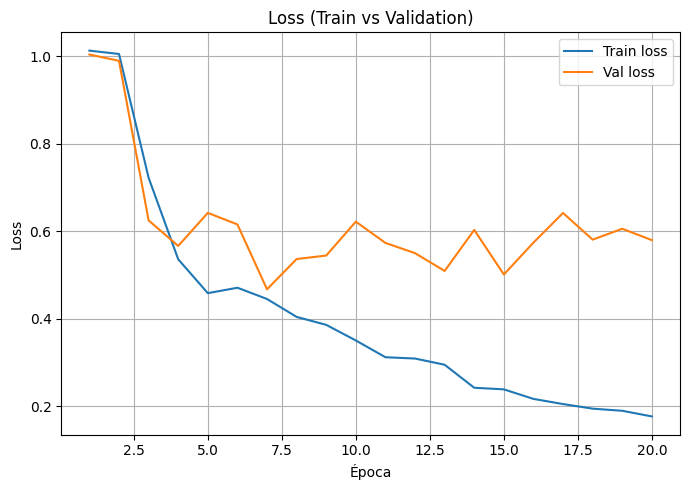

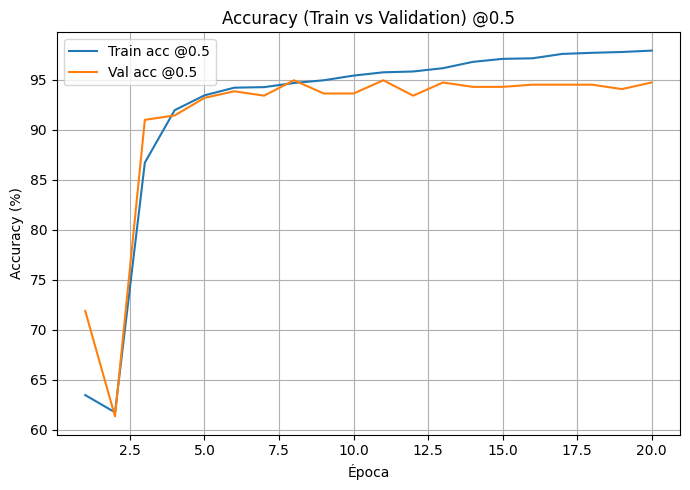

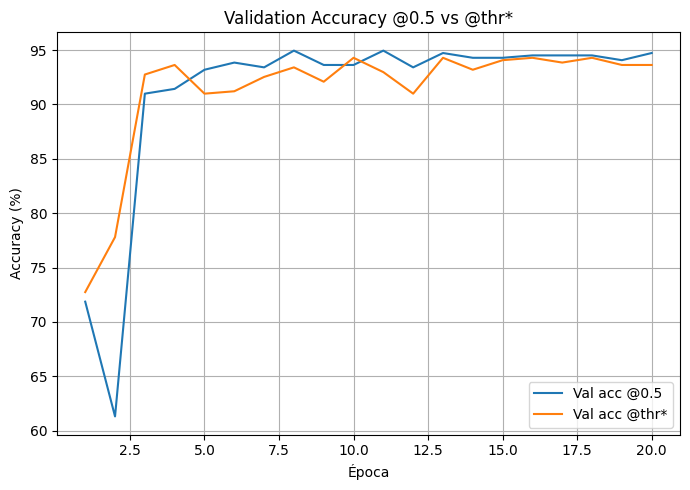

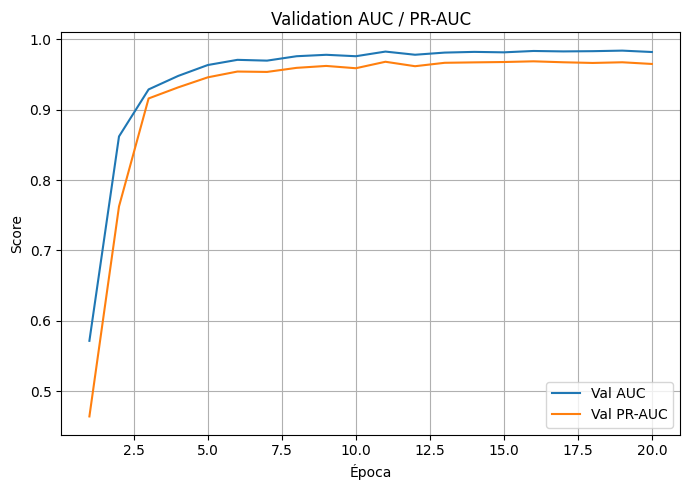

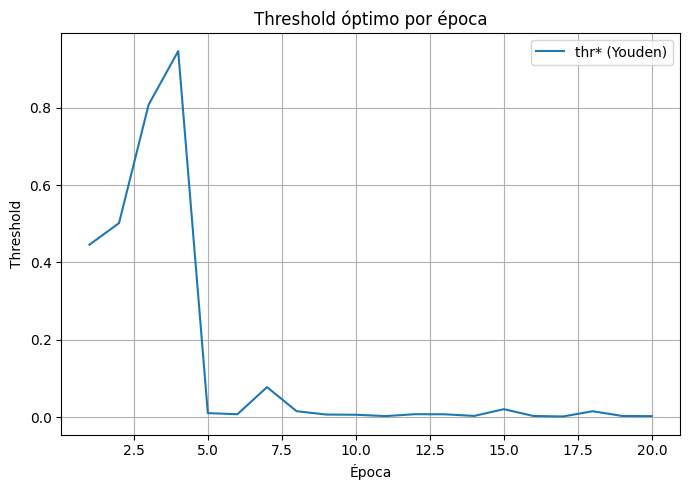

In [20]:
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["tr_loss"], label="Train loss")
plt.plot(epochs, history["va_loss"], label="Val loss")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.title("Loss (Train vs Validation)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, np.array(history["tr_acc05"]) * 100, label="Train acc @0.5")
plt.plot(epochs, np.array(history["va_acc05"]) * 100, label="Val acc @0.5")
plt.xlabel("Época"); plt.ylabel("Accuracy (%)")
plt.title("Accuracy (Train vs Validation) @0.5")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, np.array(history["va_acc05"]) * 100, label="Val acc @0.5")
plt.plot(epochs, np.array(history["va_accth"]) * 100, label="Val acc @thr*")
plt.xlabel("Época"); plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_auc"], label="Val AUC")
plt.plot(epochs, history["va_pr"], label="Val PR-AUC")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation AUC / PR-AUC")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_thr"], label="thr* (Youden)")
plt.xlabel("Época"); plt.ylabel("Threshold")
plt.title("Threshold óptimo por época")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# 18) EVALUACIÓN EN TEST

In [21]:
@torch.no_grad()
def eval_test(loader, thr, expected_targets=None, tag="test"):
    model.eval()
    all_logits, all_y = [], []
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / total
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)

    if expected_targets is not None:
        verify_supports(y_true, expected_targets, tag=f"{tag}_final")

    probs = sigmoid_np(logits)
    y_hat = (probs >= thr).astype(int)

    cm, tn, fp, fn, tp = confusion_terms(y_true, y_hat)

    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")

    try:
        pr_auc = average_precision_score(y_true, probs)
    except Exception:
        pr_auc = float("nan")

    acc = accuracy_score(y_true, y_hat)
    f1 = f1_score(y_true, y_hat, zero_division=0)
    bacc = balanced_acc_from_preds(y_true, y_hat)
    precision = precision_score(y_true, y_hat, zero_division=0)
    sensitivity = tp / max(1, tp + fn)
    specificity = tn / max(1, tn + fp)

    rep_dict = classification_report(
        y_true,
        y_hat,
        labels=[0, 1],
        target_names=[NEG_NAME, POS_NAME],
        digits=3,
        output_dict=True,
        zero_division=0
    )

    rep_txt = classification_report(
        y_true,
        y_hat,
        labels=[0, 1],
        target_names=[NEG_NAME, POS_NAME],
        digits=3,
        zero_division=0
    )

    supports_report = {
        NEG_NAME: int(rep_dict[NEG_NAME]["support"]),
        POS_NAME: int(rep_dict[POS_NAME]["support"]),
    }

    supports_expected = {
        NEG_NAME: int((np.asarray(expected_targets) == 0).sum()) if expected_targets is not None else None,
        POS_NAME: int((np.asarray(expected_targets) == 1).sum()) if expected_targets is not None else None,
    }

    return {
        "loss": avg_loss,
        "acc": float(acc),
        "f1": float(f1),
        "bacc": float(bacc),
        "precision": float(precision),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "auc": float(auc),
        "pr_auc": float(pr_auc),
        "cm": cm,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "report": rep_txt,
        "report_dict": rep_dict,
        "supports_report": supports_report,
        "supports_expected": supports_expected,
        "y_true": y_true,
        "probs": probs,
        "logits": logits,
        "thr": float(thr)
    }

def print_test(tag, res):
    print(f"\n[{tag}] thr={res['thr']:.3f}")
    print(
        f"loss={res['loss']:.4f} | acc={res['acc']*100:.1f}% | "
        f"F1={res['f1']:.3f} | bAcc={res['bacc']:.3f} | "
        f"Sens={res['sensitivity']:.3f} | Spec={res['specificity']:.3f} | "
        f"Prec={res['precision']:.3f}"
    )
    print(f"AUC={res['auc']:.3f} | PR-AUC={res['pr_auc']:.3f}")
    print("CM:\n", res["cm"])
    print("Supports esperados :", res["supports_expected"])
    print("Supports en reporte:", res["supports_report"])
    print("Reporte:\n", res["report"])

def load_checkpoint_from_registry(registry_key):
    ckpt = best_models[registry_key]
    model.load_state_dict({k: v.to(DEVICE) for k, v in ckpt["state"].items()})
    return ckpt["thr"], ckpt["epoch"]

# 19) EVALUAR TODOS LOS MEJORES CHECKPOINTS EN TEST

In [22]:
test_results_by_ckpt = {}

for ck_name in ["val_loss", "val_bacc_th", "val_f1_th", "val_auc"]:
    thr_ck, ep_ck = load_checkpoint_from_registry(ck_name)

    res_05 = eval_test(test_loader, 0.5, expected_targets=test_targets, tag=f"{ck_name}_test05")
    res_th = eval_test(test_loader, thr_ck, expected_targets=test_targets, tag=f"{ck_name}_testthr")

    test_results_by_ckpt[ck_name] = {
        "epoch": ep_ck,
        "thr_val": thr_ck,
        "test@0.5": res_05,
        "test@thr*": res_th
    }

    print(f"\n{'='*80}")
    print(f"CHECKPOINT: {ck_name} | epoch={ep_ck} | thr_val={thr_ck:.3f}")
    print_test(f"{ck_name} -> TEST @0.5", res_05)
    print_test(f"{ck_name} -> TEST @thr*", res_th)


[Support Check] val_loss_test05_final
  y_true    -> NEG=327 POS=128 total=455
  expected  -> NEG=327 POS=128 total=455
 val_loss_test05_final: supports consistentes

[Support Check] val_loss_testthr_final
  y_true    -> NEG=327 POS=128 total=455
  expected  -> NEG=327 POS=128 total=455
 val_loss_testthr_final: supports consistentes

CHECKPOINT: val_loss | epoch=7 | thr_val=0.078

[val_loss -> TEST @0.5] thr=0.500
loss=0.4165 | acc=94.1% | F1=0.897 | bAcc=0.935 | Sens=0.922 | Spec=0.948 | Prec=0.874
AUC=0.974 | PR-AUC=0.944
CM:
 [[310  17]
 [ 10 118]]
Supports esperados : {'Normal': 327, 'COVID-19': 128}
Supports en reporte: {'Normal': 327, 'COVID-19': 128}
Reporte:
               precision    recall  f1-score   support

      Normal      0.969     0.948     0.958       327
    COVID-19      0.874     0.922     0.897       128

    accuracy                          0.941       455
   macro avg      0.921     0.935     0.928       455
weighted avg      0.942     0.941     0.941       4

# 20) ELEGIR UNO PARA GRÁFICAS FINALES

In [23]:
FINAL_CKPT_NAME = "val_bacc_th"

thr_final, ep_final = load_checkpoint_from_registry(FINAL_CKPT_NAME)
res05_final  = eval_test(test_loader, 0.5, expected_targets=test_targets, tag="final_test05")
resthr_final = eval_test(test_loader, thr_final, expected_targets=test_targets, tag="final_testthr")

print(f"\n[Info] Checkpoint final seleccionado para gráficas: {FINAL_CKPT_NAME} (epoch={ep_final}, thr={thr_final:.3f})")


[Support Check] final_test05_final
  y_true    -> NEG=327 POS=128 total=455
  expected  -> NEG=327 POS=128 total=455
 final_test05_final: supports consistentes

[Support Check] final_testthr_final
  y_true    -> NEG=327 POS=128 total=455
  expected  -> NEG=327 POS=128 total=455
 final_testthr_final: supports consistentes

[Info] Checkpoint final seleccionado para gráficas: val_bacc_th (epoch=13, thr=0.007)


# 21) ROC, PR Y BARRIDO DE THRESHOLD

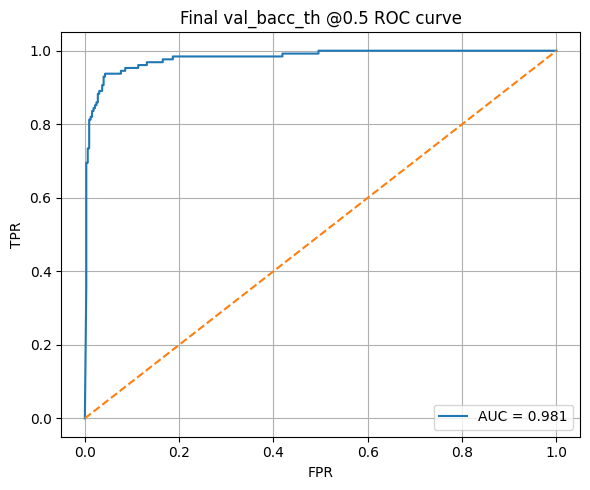

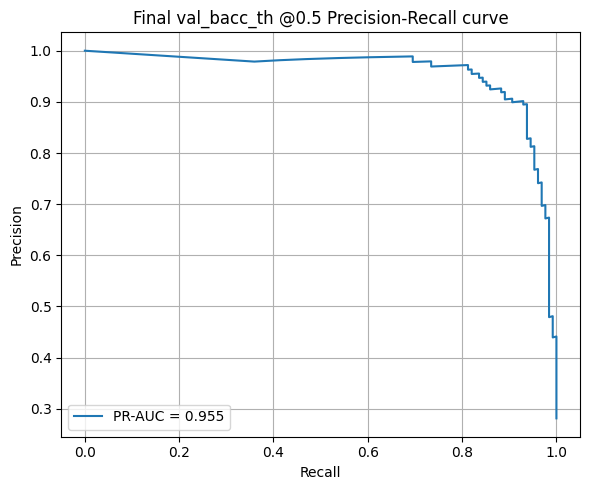

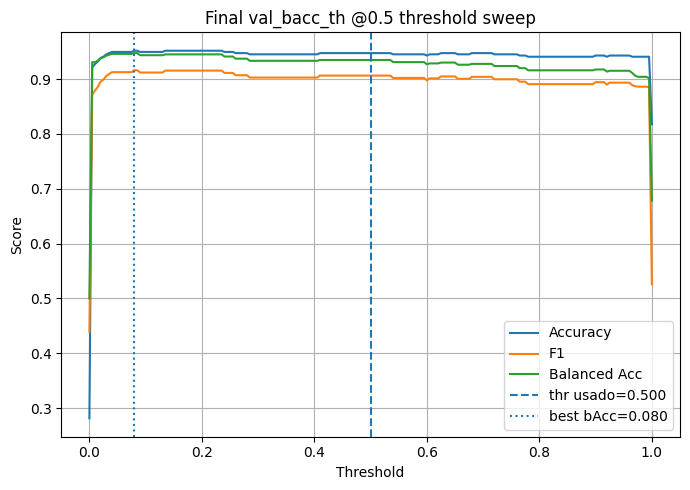

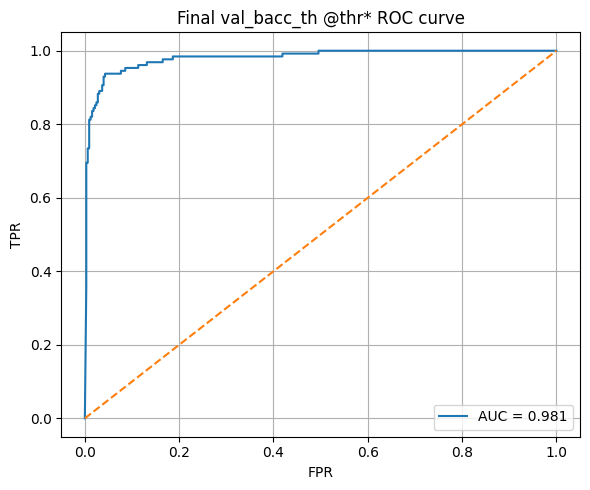

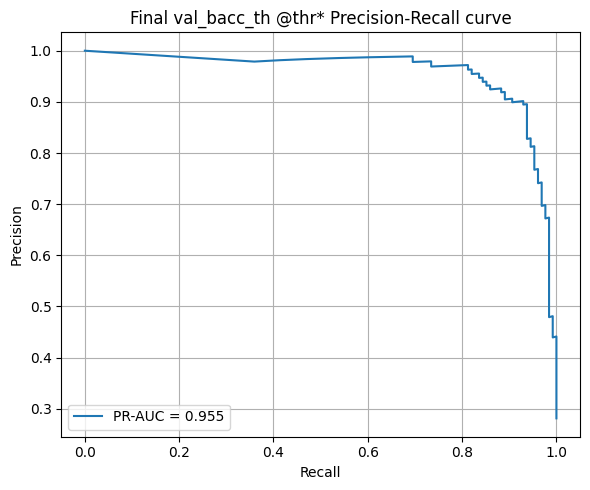

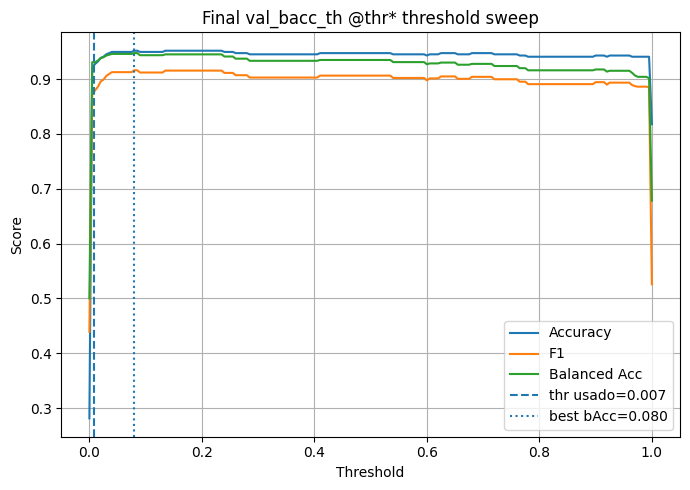

In [24]:
def plot_roc_pr_and_thresholds(res, title_prefix="Test"):
    y_true = res["y_true"]
    probs = res["probs"]

    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {res['auc']:.3f}")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    prec, rec, _ = precision_recall_curve(y_true, probs)
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label=f"PR-AUC = {res['pr_auc']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    sw = sweep_thresholds(y_true, probs, n_points=201)
    best_idx_bacc = int(np.argmax(sw["bacc"]))

    plt.figure(figsize=(7,5))
    plt.plot(sw["thresholds"], sw["acc"], label="Accuracy")
    plt.plot(sw["thresholds"], sw["f1"], label="F1")
    plt.plot(sw["thresholds"], sw["bacc"], label="Balanced Acc")
    plt.axvline(res["thr"], linestyle="--", label=f"thr usado={res['thr']:.3f}")
    plt.axvline(sw["thresholds"][best_idx_bacc], linestyle=":", label=f"best bAcc={sw['thresholds'][best_idx_bacc]:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} threshold sweep")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc_pr_and_thresholds(res05_final, title_prefix=f"Final {FINAL_CKPT_NAME} @0.5")
plot_roc_pr_and_thresholds(resthr_final, title_prefix=f"Final {FINAL_CKPT_NAME} @thr*")

In [25]:
# =========================================================
# 22) TABLA RESUMEN DE TODOS LOS CHECKPOINTS
# =========================================================
summary_rows = []
for ck_name, pack in test_results_by_ckpt.items():
    r05 = pack["test@0.5"]
    rth = pack["test@thr*"]

    summary_rows.append({
        "checkpoint": ck_name,
        "epoch": pack["epoch"],
        "thr_val": pack["thr_val"],

        "test_acc@0.5": r05["acc"],
        "test_f1@0.5": r05["f1"],
        "test_bacc@0.5": r05["bacc"],
        "test_sens@0.5": r05["sensitivity"],
        "test_spec@0.5": r05["specificity"],
        "test_auc": r05["auc"],
        "test_pr_auc": r05["pr_auc"],

        "test_acc@thr*": rth["acc"],
        "test_f1@thr*": rth["f1"],
        "test_bacc@thr*": rth["bacc"],
        "test_sens@thr*": rth["sensitivity"],
        "test_spec@thr*": rth["specificity"],
    })

print("\n" + "=" * 150)
print("TABLA RESUMEN DE CHECKPOINTS")
print("=" * 150)
for row in summary_rows:
    print(
        f"{row['checkpoint']:12s} | epoch={row['epoch']:2d} | thr={row['thr_val']:.3f} | "
        f"acc@0.5={row['test_acc@0.5']:.4f} | f1@0.5={row['test_f1@0.5']:.4f} | "
        f"bacc@0.5={row['test_bacc@0.5']:.4f} | sens@0.5={row['test_sens@0.5']:.4f} | "
        f"spec@0.5={row['test_spec@0.5']:.4f} | auc={row['test_auc']:.4f} | "
        f"pr_auc={row['test_pr_auc']:.4f} | acc@thr*={row['test_acc@thr*']:.4f} | "
        f"f1@thr*={row['test_f1@thr*']:.4f} | bacc@thr*={row['test_bacc@thr*']:.4f} | "
        f"sens@thr*={row['test_sens@thr*']:.4f} | spec@thr*={row['test_spec@thr*']:.4f}"
    )



TABLA RESUMEN DE CHECKPOINTS
val_loss     | epoch= 7 | thr=0.078 | acc@0.5=0.9407 | f1@0.5=0.8973 | bacc@0.5=0.9349 | sens@0.5=0.9219 | spec@0.5=0.9480 | auc=0.9738 | pr_auc=0.9435 | acc@thr*=0.9077 | f1@thr*=0.8511 | bacc@thr*=0.9168 | sens@thr*=0.9375 | spec@thr*=0.8960
val_bacc_th  | epoch=13 | thr=0.007 | acc@0.5=0.9473 | f1@0.5=0.9062 | bacc@0.5=0.9348 | sens@0.5=0.9062 | spec@0.5=0.9633 | auc=0.9808 | pr_auc=0.9550 | acc@thr*=0.9253 | f1@thr*=0.8768 | bacc@thr*=0.9314 | sens@thr*=0.9453 | spec@thr*=0.9174
val_f1_th    | epoch=13 | thr=0.007 | acc@0.5=0.9473 | f1@0.5=0.9062 | bacc@0.5=0.9348 | sens@0.5=0.9062 | spec@0.5=0.9633 | auc=0.9808 | pr_auc=0.9550 | acc@thr*=0.9253 | f1@thr*=0.8768 | bacc@thr*=0.9314 | sens@thr*=0.9453 | spec@thr*=0.9174
val_auc      | epoch=19 | thr=0.003 | acc@0.5=0.9495 | f1@0.5=0.9105 | bacc@0.5=0.9387 | sens@0.5=0.9141 | spec@0.5=0.9633 | auc=0.9815 | pr_auc=0.9581 | acc@thr*=0.9209 | f1@thr*=0.8705 | bacc@thr*=0.9283 | sens@thr*=0.9453 | spec@thr*=0

In [26]:
# =========================================================
# 23) RESUMEN FINAL
# =========================================================
print("\n" + "=" * 70)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("=" * 70)
print(f"Parámetros totales       : {total_p:,}")
print(f"Parámetros cuánticos     : {quantum_p:,}")
print(f"Parámetros clásicos      : {classical_p:,}")

print("\nMejores checkpoints en validación:")
for k, v in best_models.items():
    print(f" - {k}: epoch={v['epoch']} | best={v['best']:.6f} | thr={v['thr']:.3f}")

print(f"\nCheckpoint final usado para curvas: {FINAL_CKPT_NAME}")
print(f"Epoch final: {ep_final}")
print(f"Threshold final: {thr_final:.4f}")

print("\n--- Final Test @0.5 ---")
print(
    f"loss={res05_final['loss']:.4f} | "
    f"acc={res05_final['acc']:.4f} | "
    f"f1={res05_final['f1']:.4f} | "
    f"bAcc={res05_final['bacc']:.4f} | "
    f"sens={res05_final['sensitivity']:.4f} | "
    f"spec={res05_final['specificity']:.4f} | "
    f"prec={res05_final['precision']:.4f} | "
    f"auc={res05_final['auc']:.4f} | "
    f"pr_auc={res05_final['pr_auc']:.4f}"
)
print("CM @0.5:\n", res05_final["cm"])
print("Supports esperados @0.5 :", res05_final["supports_expected"])
print("Supports reporte  @0.5 :", res05_final["supports_report"])

print("\n--- Final Test @thr* ---")
print(
    f"loss={resthr_final['loss']:.4f} | "
    f"acc={resthr_final['acc']:.4f} | "
    f"f1={resthr_final['f1']:.4f} | "
    f"bAcc={resthr_final['bacc']:.4f} | "
    f"sens={resthr_final['sensitivity']:.4f} | "
    f"spec={resthr_final['specificity']:.4f} | "
    f"prec={resthr_final['precision']:.4f} | "
    f"auc={resthr_final['auc']:.4f} | "
    f"pr_auc={resthr_final['pr_auc']:.4f}"
)
print("CM @thr*:\n", resthr_final["cm"])
print("Supports esperados @thr* :", resthr_final["supports_expected"])
print("Supports reporte  @thr* :", resthr_final["supports_report"])


RESUMEN FINAL DEL EXPERIMENTO
Parámetros totales       : 6,341
Parámetros cuánticos     : 80
Parámetros clásicos      : 6,261

Mejores checkpoints en validación:
 - val_loss: epoch=7 | best=0.467442 | thr=0.078
 - val_bacc_th: epoch=13 | best=0.948359 | thr=0.007
 - val_f1_th: epoch=13 | best=0.904412 | thr=0.007
 - val_auc: epoch=19 | best=0.983849 | thr=0.003

Checkpoint final usado para curvas: val_bacc_th
Epoch final: 13
Threshold final: 0.0074

--- Final Test @0.5 ---
loss=0.4940 | acc=0.9473 | f1=0.9062 | bAcc=0.9348 | sens=0.9062 | spec=0.9633 | prec=0.9062 | auc=0.9808 | pr_auc=0.9550
CM @0.5:
 [[315  12]
 [ 12 116]]
Supports esperados @0.5 : {'Normal': 327, 'COVID-19': 128}
Supports reporte  @0.5 : {'Normal': 327, 'COVID-19': 128}

--- Final Test @thr* ---
loss=0.4940 | acc=0.9253 | f1=0.8768 | bAcc=0.9314 | sens=0.9453 | spec=0.9174 | prec=0.8176 | auc=0.9808 | pr_auc=0.9550
CM @thr*:
 [[300  27]
 [  7 121]]
Supports esperados @thr* : {'Normal': 327, 'COVID-19': 128}
Support